    # MODULO5 Talento Altamente Especializado --> IA

    *Professor**: Dr German Pinedo
    **Nombre**: Cesar Eduardo Inda Ceniceros  

# M5.4 Variational Autoencoder (VAE)

A variational autoencoder represents each image with a **distribution**, not with one fixed latent point:

$$x \rightarrow \text{Encoder} \rightarrow (\mu,\log\sigma^2) \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x}$$

This notebook uses MNIST resized to $32\times32$. We first build the KL term step by step, then train a small convolutional VAE with

$$\mathcal{L}_{VAE}=\mathcal{L}_{rec}+\beta\mathcal{L}_{KL}.$$

In [1]:
!pip install torchinfo
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchinfo import summary

EPOCHS = 10
BATCH_SIZE = 64
TRAIN_SAMPLES = 2000
LATENT_DIM = 2
BETA = 1.0

torch.manual_seed(42)
np.random.seed(42)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: cuda


## KL divergence, step by step

### Step 1 — The encoder defines a distribution

For each image, the encoder predicts the parameters of a diagonal Gaussian:

$$q_\phi(z\mid x)=\mathcal{N}\!\left(\mu,\operatorname{diag}(\sigma^2)\right).$$

It outputs `mu` $=\mu$ and `logvar` $=\log\sigma^2$. Predicting the log-variance avoids constraining a network output to be positive; the variance is recovered with $\sigma^2=\exp(\text{logvar})$.

### Step 2 — Compare the posterior with a simple prior

We want latent codes that can be sampled from the standard normal prior

$$p(z)=\mathcal{N}(0,I).$$

The Kullback–Leibler divergence measures how different the encoder distribution is from that prior:

$$D_{KL}\!\left(q_\phi(z\mid x)\parallel p(z)\right)
=\mathbb{E}_{q_\phi}\!\left[\log\frac{q_\phi(z\mid x)}{p(z)}\right]\geq 0.$$

The order matters: a VAE uses $D_{KL}(q\parallel p)$. It is zero when $q_\phi(z\mid x)=p(z)$.

### Step 3 — Derive the closed form for one coordinate

For $q(z_j\mid x)=\mathcal{N}(\mu_j,\sigma_j^2)$ and $p(z_j)=\mathcal{N}(0,1)$,

$$\log q=-\frac{1}{2}\log(2\pi\sigma_j^2)-\frac{(z_j-\mu_j)^2}{2\sigma_j^2},$$

$$\log p=-\frac{1}{2}\log(2\pi)-\frac{z_j^2}{2}.$$

Under $q$, $\mathbb{E}[(z_j-\mu_j)^2]=\sigma_j^2$ and $\mathbb{E}[z_j^2]=\mu_j^2+\sigma_j^2$. Substituting these expectations into $\mathbb{E}_q[\log q-\log p]$ gives

$$D_{KL,j}=\frac{1}{2}\left(\mu_j^2+\sigma_j^2-1-\log\sigma_j^2\right).$$

### Step 4 — Use `logvar` and reduce the dimensions

Since $\sigma_j^2=\exp(\text{logvar}_j)$,

$$D_{KL,j}=-\frac{1}{2}\left(1+\text{logvar}_j-\mu_j^2-\exp(\text{logvar}_j)\right).$$

For each image, sum over its $d$ latent coordinates; for a batch of $B$ images, average those sums:

$$\mathcal{L}_{KL}=\frac{1}{B}\sum_{i=1}^{B}\sum_{j=1}^{d}D_{KL,ij}.$$

The $\mu^2$ term moves means toward $0$, while the variance terms are minimized at $\sigma^2=1$. Therefore KL encourages a continuous, sampleable latent space.

**Exercise:** implement this formula below. Compute each latent contribution first, then sum latent dimensions and average the batch.

In [2]:
def kl_divergence(mu, logvar):
    'Sum latent dimensions, then average the batch.'
    # TODO 1a: Compute KL per coordinate; hint: -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())

    # TODO 1b: Reduce the KL values; hint: sum(dim=1), then mean().
    return kl_per_dim.sum(dim=1).mean()

# Three one-dimensional examples: the prior, a shifted mean, and a wide variance.
mu_demo = torch.tensor([[0.0], [1.0], [0.0]])
variance_demo = torch.tensor([[1.0], [1.0], [4.0]])
logvar_demo = variance_demo.log()

kl_demo = 0.5 * (
    mu_demo.pow(2) + variance_demo - 1 - logvar_demo
).sum(dim=1)

for mu_i, var_i, kl_i in zip(mu_demo, variance_demo, kl_demo):
    print(
        f"mu={mu_i.item():.1f}, variance={var_i.item():.1f} "
        f"-> KL={kl_i.item():.4f}"
    )

# Verify the formula against PyTorch's distribution implementation.
q_demo = torch.distributions.Normal(mu_demo, variance_demo.sqrt())
p_demo = torch.distributions.Normal(
    torch.zeros_like(mu_demo), torch.ones_like(mu_demo)
)
kl_reference = torch.distributions.kl_divergence(q_demo, p_demo).sum(dim=1)

torch.testing.assert_close(kl_demo, kl_reference)
torch.testing.assert_close(kl_divergence(mu_demo, logvar_demo), kl_demo.mean())
assert torch.all(kl_demo >= -1e-7)
print("Checks passed: KL is non-negative and matches PyTorch.")

mu=0.0, variance=1.0 -> KL=0.0000
mu=1.0, variance=1.0 -> KL=0.5000
mu=0.0, variance=4.0 -> KL=0.8069
Checks passed: KL is non-negative and matches PyTorch.


### Step 5 — Sample while keeping gradients

Sampling $z\sim q_\phi(z\mid x)$ directly would interrupt backpropagation. The reparameterization trick moves the randomness into an independent variable:

$$\epsilon\sim\mathcal{N}(0,I),\qquad
\sigma=\exp\!\left(\tfrac{1}{2}\text{logvar}\right),\qquad
z=\mu+\sigma\odot\epsilon.$$

Notice the two exponentials: sampling uses the **standard deviation** `exp(0.5 * logvar)`, while KL uses the **variance** `exp(logvar)`.

For MNIST, we sum binary cross-entropy over pixels and average over the batch. The total loss balances image reconstruction against latent regularity. With $\beta=1$, this is the standard VAE objective.

**Exercise:** compute the reconstruction loss and combine it with KL as $\mathcal{L}_{VAE}=\mathcal{L}_{rec}+\beta\mathcal{L}_{KL}$.

In [3]:
def vae_loss(reconstruction, target, mu, logvar, beta=BETA):
    'Return total, reconstruction, and KL losses per image.'
    # TODO 2a: Sum BCE over pixels per image; hint: reduction="none", flatten(1), then sum(dim=1).
    reconstruction_per_image = F.binary_cross_entropy(
        reconstruction, target, reduction='none'
    ).flatten(1).sum(dim=1)

    # TODO 2b: Average over the batch; hint: call mean() on reconstruction_per_image.
    reconstruction_loss = reconstruction_per_image.mean()

    # TODO 2c: Compute KL and total loss; hint: call kl_divergence then sum kl plus reconstruction.
    kl_loss = kl_divergence(mu, logvar)
    total_loss = reconstruction_loss + beta * kl_loss
    return total_loss, reconstruction_loss, kl_loss


def collect_latents(model, loader):
    'Use posterior means as deterministic latent representations.'
    was_training = model.training
    model.eval()
    means, labels = [], []

    with torch.no_grad():
        for images, y in loader:
            mu, _ = model.encode(images.to(device))
            means.append(mu.cpu())
            labels.append(y)

    if was_training:
        model.train()

    return torch.cat(means).numpy(), torch.cat(labels).numpy()


def train_vae(model, loader, epochs=EPOCHS, lr=1e-3):
    'Train the VAE and report every part of its objective.'
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"total": [], "reconstruction": [], "kl": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = {name: 0.0 for name in history}

        for images, _ in loader:
            images = images.to(device)

            optimizer.zero_grad()
            reconstruction, mu, logvar = model(images)
            total_loss, reconstruction_loss, kl_loss = vae_loss(
                reconstruction, images, mu, logvar
            )
            total_loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            running["total"] += total_loss.item() * batch_size
            running["reconstruction"] += reconstruction_loss.item() * batch_size
            running["kl"] += kl_loss.item() * batch_size

        for name in history:
            history[name].append(running[name] / len(loader.dataset))

        if epoch == 1 or epoch % 2 == 0 or epoch == epochs:
            print(
                f"epoch {epoch:2d}/{epochs} - "
                f"total: {history['total'][-1]:.3f} - "
                f"reconstruction: {history['reconstruction'][-1]:.3f} - "
                f"KL: {history['kl'][-1]:.3f}"
            )

    return history

## 2D convolutional VAE

The encoder reduces a $32\times32$ image to a feature vector and produces separate `mu` and `logvar` heads. The decoder maps a sampled latent vector back to an image.

To sample while preserving gradients, use $\sigma=\exp(0.5\,\text{logvar})$, draw $\epsilon$ with `randn_like`, and return $z=\mu+\sigma\odot\epsilon$.

**Exercise:** complete `reparameterize` with these three operations.

In [4]:
class ConvVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.feature_shape = (64, 4, 4)
        feature_dim = int(np.prod(self.feature_shape))

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(feature_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, feature_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        features = self.encoder(x)
        return self.fc_mu(features), self.fc_logvar(features)

    def reparameterize(self, mu, logvar):
    # TODO 3a: Recover the standard deviation; hint: torch.exp(0.5 * logvar).
      std = torch.exp(0.5 * logvar)

    # TODO 3b: Sample and construct z; hint: torch.randn_like(std), then mu + std * epsilon.
      epsilon = torch.randn_like(std)
      return mu + std * epsilon

    def decode(self, z):
        features = self.fc_decode(z)
        features = features.view(z.size(0), *self.feature_shape)
        return self.decoder(features)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

Training samples: 2000
Training batches: 32


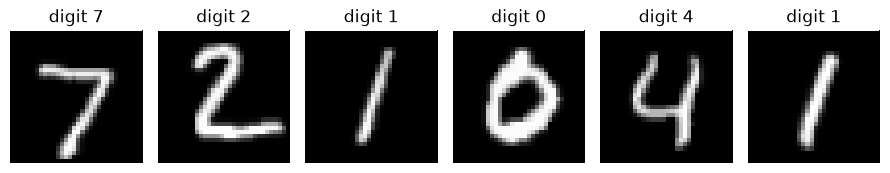

In [5]:
# MNIST: [1, 28, 28] -> [1, 32, 32]
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_dataset_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

generator = torch.Generator().manual_seed(42)
train_indices = torch.randperm(
    len(train_dataset_full), generator=generator
)[:TRAIN_SAMPLES]
train_dataset = Subset(train_dataset_full, train_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)
latent_loader = DataLoader(
    Subset(test_dataset, range(1500)),
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

print(f"Training samples: {len(train_dataset)}")
print(f"Training batches: {len(train_loader)}")

x_test, y_test = next(iter(test_loader))
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i, 0], cmap="gray")
    ax.set_title(f"digit {y_test[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
vae = ConvVAE(in_channels=1, latent_dim=LATENT_DIM)
x_sample, _ = next(iter(train_loader))

summary(
    vae,
    input_data=x_sample[:1],
    col_names=("input_size", "output_size", "num_params"),
    depth=3,
)

with torch.no_grad():
    reconstruction_sample, mu_sample, logvar_sample = vae(x_sample[:4])

print("reconstruction:", tuple(reconstruction_sample.shape))
print("mu:", tuple(mu_sample.shape))
print("logvar:", tuple(logvar_sample.shape))

reconstruction: (4, 1, 32, 32)
mu: (4, 2)
logvar: (4, 2)


## Training

Tracking reconstruction and KL separately makes their trade-off visible. The total curve is exactly `reconstruction + BETA * KL`.

epoch  1/10 - total: 517.568 - reconstruction: 505.151 - KL: 12.417
epoch  2/10 - total: 289.925 - reconstruction: 281.643 - KL: 8.282
epoch  4/10 - total: 268.287 - reconstruction: 262.831 - KL: 5.455
epoch  6/10 - total: 255.908 - reconstruction: 251.259 - KL: 4.649
epoch  8/10 - total: 240.530 - reconstruction: 235.492 - KL: 5.038
epoch 10/10 - total: 236.120 - reconstruction: 231.146 - KL: 4.974


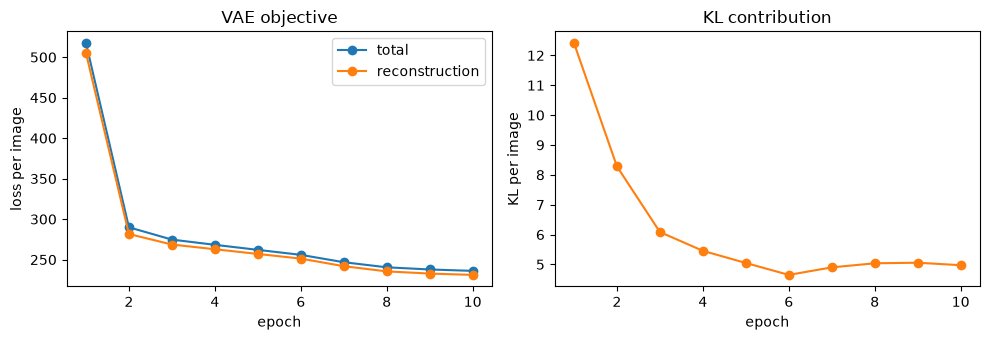

In [7]:
history = train_vae(vae, train_loader)

epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(epochs, history["total"], marker="o", label="total")
axes[0].plot(
    epochs, history["reconstruction"], marker="o", label="reconstruction"
)
axes[0].set_title("VAE objective")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss per image")
axes[0].legend()

axes[1].plot(epochs, history["kl"], marker="o", color="tab:orange")
axes[1].set_title("KL contribution")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("KL per image")

plt.tight_layout()
plt.show()

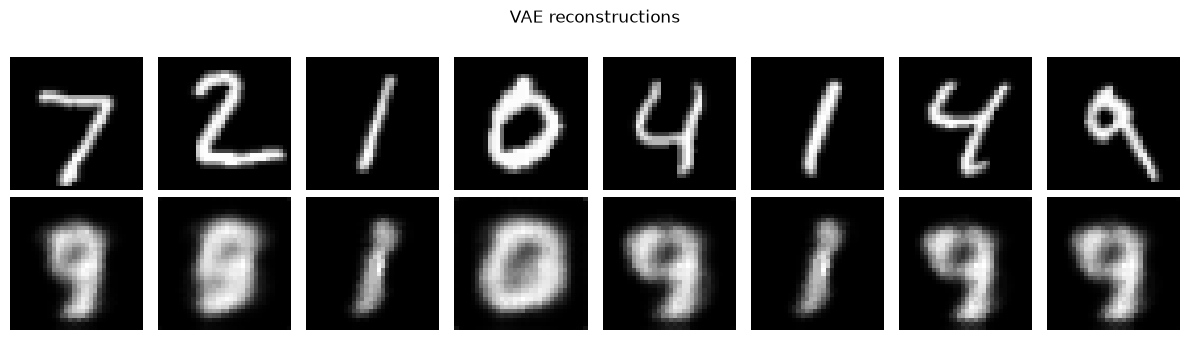

In [8]:
vae.eval()
with torch.no_grad():
    reconstructions, _, _ = vae(x_test[:8].to(device))
reconstructions = reconstructions.cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0, i].imshow(x_test[i, 0], cmap="gray")
    axes[1, i].imshow(reconstructions[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstruction")
fig.suptitle("VAE reconstructions")
plt.tight_layout()
plt.show()

## Sampling from the prior

Because KL keeps the learned posteriors near $\mathcal{N}(0,I)$, we can draw new latent vectors from that prior and send them directly to the decoder. In PyTorch, `torch.randn` produces standard-normal samples.

**Exercise:** create a batch of 10 prior samples with shape `(10, LATENT_DIM)`.

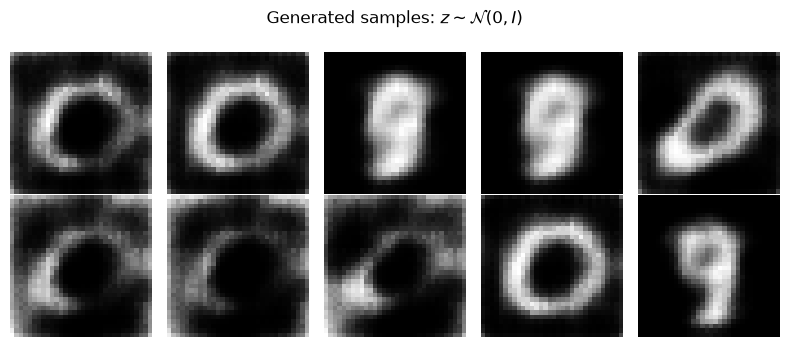

In [9]:
torch.manual_seed(7)
# TODO 4: Sample 10 prior vectors; hint: torch.randn(10, LATENT_DIM, device=device).
z_prior = torch.randn(10, LATENT_DIM, device=device)

with torch.no_grad():
    generated = vae.decode(z_prior).cpu()

fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for image, ax in zip(generated, axes.flat):
    ax.imshow(image[0], cmap="gray")
    ax.axis("off")
fig.suptitle(r"Generated samples: $z \sim \mathcal{N}(0,I)$")
plt.tight_layout()
plt.show()

## Latent space

With `LATENT_DIM = 2`, no projection method is needed. We plot the posterior mean $\mu(x)$ for each test image; the labels are used only for color.

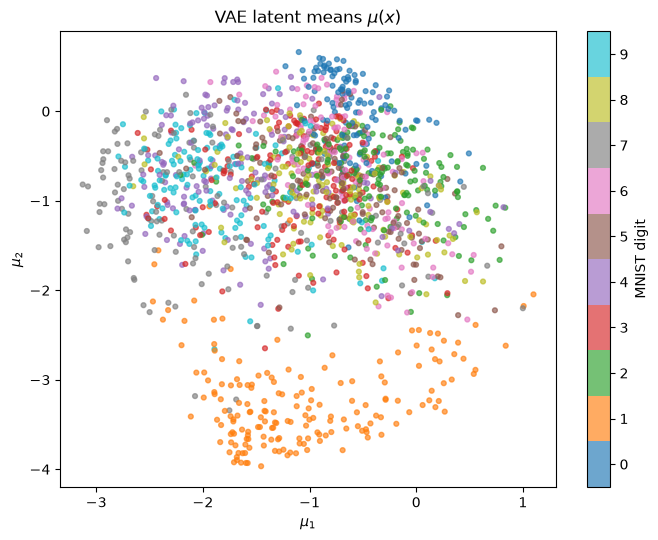

In [10]:
latent_means, latent_labels = collect_latents(vae, latent_loader)

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(
    latent_means[:, 0],
    latent_means[:, 1],
    c=latent_labels,
    cmap="tab10",
    vmin=-0.5,
    vmax=9.5,
    s=12,
    alpha=0.65,
)
ax.set_title(r"VAE latent means $\mu(x)$")
ax.set_xlabel(r"$\mu_1$")
ax.set_ylabel(r"$\mu_2$")
colorbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
colorbar.set_label("MNIST digit")
plt.tight_layout()
plt.show()

## Key points

- The encoder predicts `mu` and `logvar`, which define $q_\phi(z\mid x)$.
- Sampling uses `exp(0.5 * logvar)` because that quantity is the standard deviation.
- KL uses `exp(logvar)` because that quantity is the variance.
- KL is zero at `mu = 0` and `logvar = 0`, the standard normal prior.
- Reconstruction preserves image information; KL makes the latent space continuous and sampleable.